In [1]:
!pip install pandas numpy matplotlib scikit-learn nltk wordcloud streamlit joblib plotly textblob emoji openpyxl

In [2]:
import nltk

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to C:\Users\GADDAM
[nltk_data]     AKASH\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\GADDAM
[nltk_data]     AKASH\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\GADDAM
[nltk_data]     AKASH\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\GADDAM
[nltk_data]     AKASH\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import nltk
import joblib
import os

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [5]:
df = pd.read_csv("sent140_cleaned.csv")

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,target,text
0,0,"['switchfoot', 'thats', 'bummer', 'shoulda', '..."
1,0,"['upset', 'cant', 'update', 'facebook', 'texti..."
2,0,"['kenichan', 'dived', 'many', 'time', 'ball', ..."
3,0,"['whole', 'body', 'feel', 'itchy', 'like', 'fi..."
4,0,"['nationwideclass', 'behaving', 'mad', 'cant',..."


In [6]:
df = pd.read_csv("sent140_cleaned.csv")

In [7]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

df.info()

Shape: (1600000, 2)

Columns:
Index(['target', 'text'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   text    1600000 non-null  object
dtypes: int64(1), object(1)
memory usage: 24.4+ MB


In [8]:
print(df.isnull().sum())

target    0
text      0
dtype: int64


In [9]:
df = df.dropna()

print("New Shape:", df.shape)

New Shape: (1600000, 2)


In [11]:
print(df.columns)

Index(['target', 'text'], dtype='object')


In [12]:
# Features (tweet text)
X = df["text"]

# Labels (sentiment)
y = df["target"]

print("Features and Labels Prepared Successfully!")
print("Total Samples:", len(X))

Features and Labels Prepared Successfully!
Total Samples: 1600000


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Dataset Split Successfully!")

Dataset Split Successfully!


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

print("Vectorization Completed!")

Vectorization Completed!


In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


In [16]:
# Predict sentiment for test data
y_pred = model.predict(X_test)

print("✅ Prediction Completed!")

✅ Prediction Completed!


In [17]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 76.33 %


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.73      0.76    159494
           4       0.75      0.79      0.77    160506

    accuracy                           0.76    320000
   macro avg       0.76      0.76      0.76    320000
weighted avg       0.76      0.76      0.76    320000



In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[117021  42473]
 [ 33277 127229]]


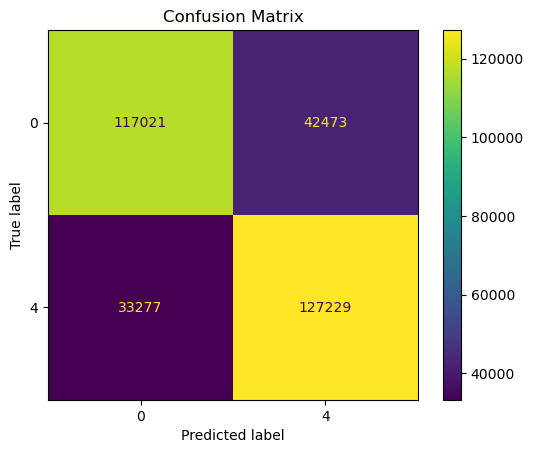

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")
plt.show()

In [21]:
import os
import joblib

# Create a folder named 'models' if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save the trained model
joblib.dump(model, "models/sentiment_model.pkl")

# Save the TF-IDF vectorizer
joblib.dump(vectorizer, "models/vectorizer.pkl")

print("✅ Model and Vectorizer saved successfully!")

✅ Model and Vectorizer saved successfully!


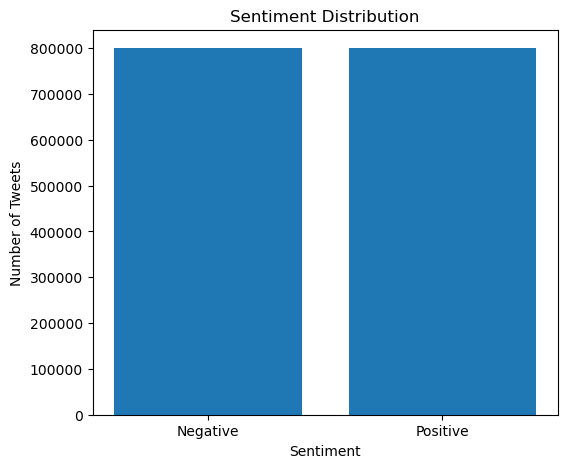

In [22]:
import matplotlib.pyplot as plt

sentiment_counts = df["target"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(["Negative", "Positive"], sentiment_counts.values)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.show()

In [23]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_text = " ".join(df[df["target"] == 1]["text"].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Tweets Word Cloud")
plt.show()

ValueError: We need at least 1 word to plot a word cloud, got 0.

In [24]:
import pandas as pd

df = pd.read_csv("sent140_cleaned.csv")

print("✅ Dataset loaded!")
print("Shape:", df.shape)
print(df.columns)

✅ Dataset loaded!
Shape: (1600000, 2)
Index(['target', 'text'], dtype='object')


In [26]:
print("Target values:")
print(df["target"].value_counts())

print("\nUnique target values:")
print(df["target"].unique())

Target values:
target
0    800000
4    800000
Name: count, dtype: int64

Unique target values:
[0 4]


Positive text characters: 55981515


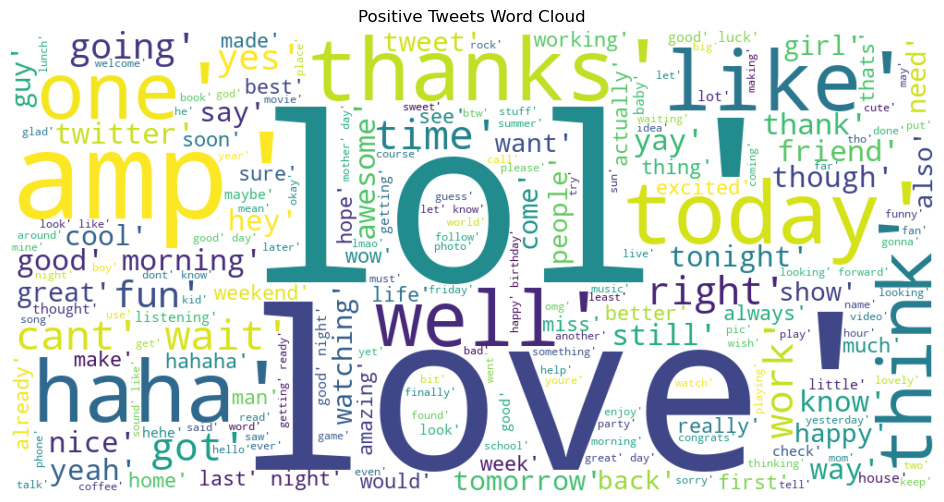

In [27]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_text = " ".join(
    df.loc[df["target"] == 4, "text"]
    .dropna()
    .astype(str)
)

print("Positive text characters:", len(positive_text))

if len(positive_text.strip()) == 0:
    print("❌ No positive text found.")
else:
    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        max_words=200
    ).generate(positive_text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Positive Tweets Word Cloud")
    plt.show()

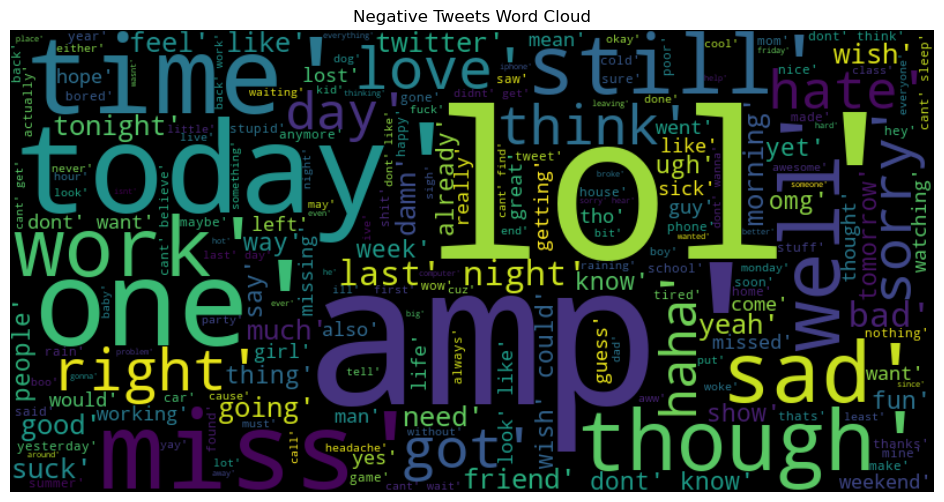

In [28]:
negative_text = " ".join(df[df["target"] == 0]["text"].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="black"
).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Tweets Word Cloud")
plt.show()

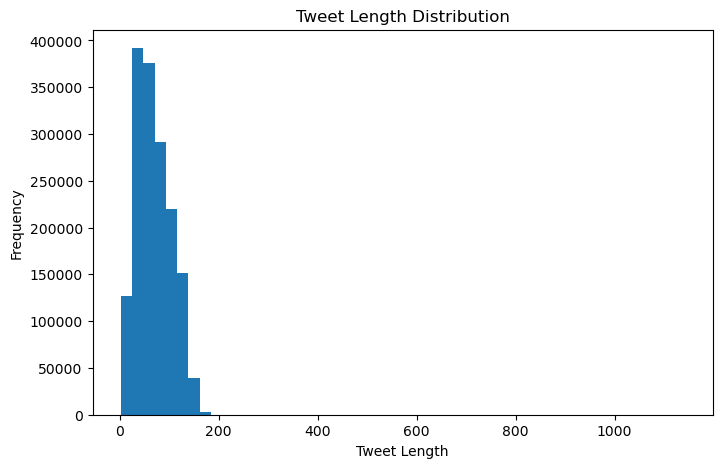

In [29]:
df["tweet_length"] = df["text"].astype(str).apply(len)

plt.figure(figsize=(8,5))
plt.hist(df["tweet_length"], bins=50)
plt.title("Tweet Length Distribution")
plt.xlabel("Tweet Length")
plt.ylabel("Frequency")
plt.show()

In [30]:
tweets = [
    "I love this phone!",
    "This service is terrible.",
    "The movie was fantastic.",
    "I hate waiting in traffic."
]

tweet_vectors = vectorizer.transform(tweets)

predictions = model.predict(tweet_vectors)

for tweet, prediction in zip(tweets, predictions):
    sentiment = "Positive 😊" if prediction == 1 else "Negative 😞"
    print(f"{tweet} --> {sentiment}")

I love this phone! --> Negative 😞
This service is terrible. --> Negative 😞
The movie was fantastic. --> Negative 😞
I hate waiting in traffic. --> Negative 😞


In [31]:
results = pd.DataFrame({
    "Tweet": tweets,
    "Prediction": ["Positive" if p == 1 else "Negative" for p in predictions]
})

results.to_csv("predictions.csv", index=False)

print("✅ Predictions saved to predictions.csv")
results

✅ Predictions saved to predictions.csv


,Tweet,Prediction
0,I love this phone!,Negative
1,This service is terrible.,Negative
2,The movie was fantastic.,Negative
3,I hate waiting in traffic.,Negative


In [32]:
from collections import Counter
import re

positive_text = " ".join(
    df[df["target"] == 1]["text"].astype(str)
)

# Extract words
positive_words = re.findall(r'\b[a-zA-Z]{3,}\b', positive_text.lower())

# Count words
positive_word_counts = Counter(positive_words)

print("Top 20 Positive Words:")
print(positive_word_counts.most_common(20))

Top 20 Positive Words:
[]


Top 20 Positive Words:
[('good', 60934), ('day', 53977), ('love', 49513), ('get', 38092), ('like', 37947), ('thanks', 33804), ('lol', 33486), ('time', 33196), ('going', 30653), ('today', 29220), ('got', 27799), ('one', 27569), ('new', 26646), ('know', 26396), ('see', 25584), ('great', 24889), ('well', 24600), ('back', 23527), ('night', 23157), ('dont', 22145)]


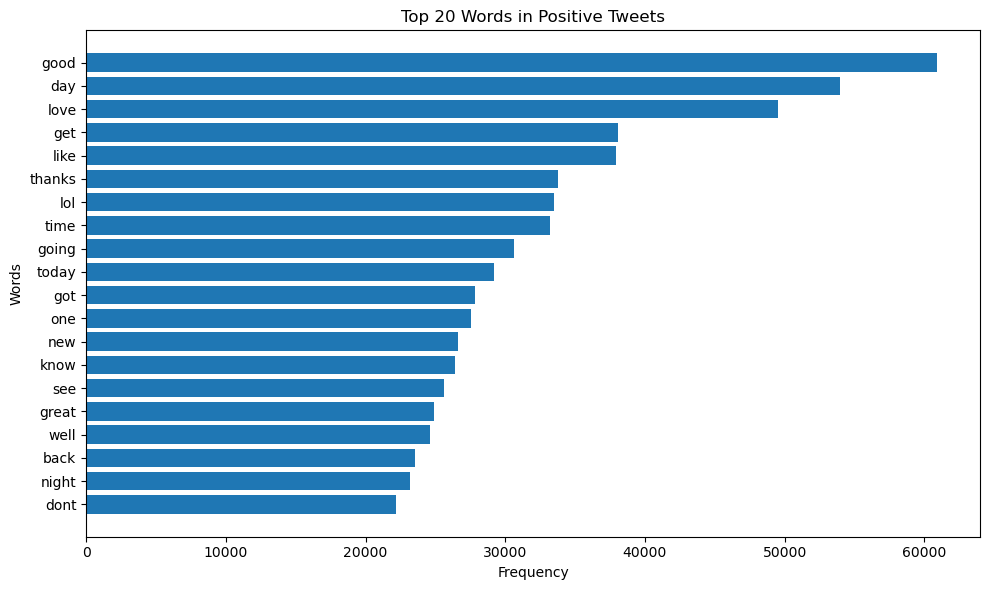

In [35]:
from collections import Counter
import re
import matplotlib.pyplot as plt

# Get positive tweets
positive_text = " ".join(
    df.loc[df["target"] == 4, "text"]
    .dropna()
    .astype(str)
)

# Extract words
positive_words = re.findall(
    r'\b[a-zA-Z]{3,}\b',
    positive_text.lower()
)

# Count words
positive_word_counts = Counter(positive_words)

# Top 20 words
top_positive = positive_word_counts.most_common(20)

print("Top 20 Positive Words:")
print(top_positive)

# Prepare chart
words = [x[0] for x in top_positive]
counts = [x[1] for x in top_positive]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(words[::-1], counts[::-1])

plt.title("Top 20 Words in Positive Tweets")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.tight_layout()
plt.show()

Top 20 Negative Words:
[('day', 50061), ('get', 47839), ('work', 45620), ('dont', 45155), ('cant', 43773), ('like', 41150), ('today', 36895), ('want', 34033), ('going', 33451), ('got', 33102), ('back', 32589), ('miss', 31742), ('really', 31230), ('time', 30605), ('still', 28779), ('good', 28597), ('one', 28314), ('sad', 27150), ('know', 26828), ('feel', 25234)]


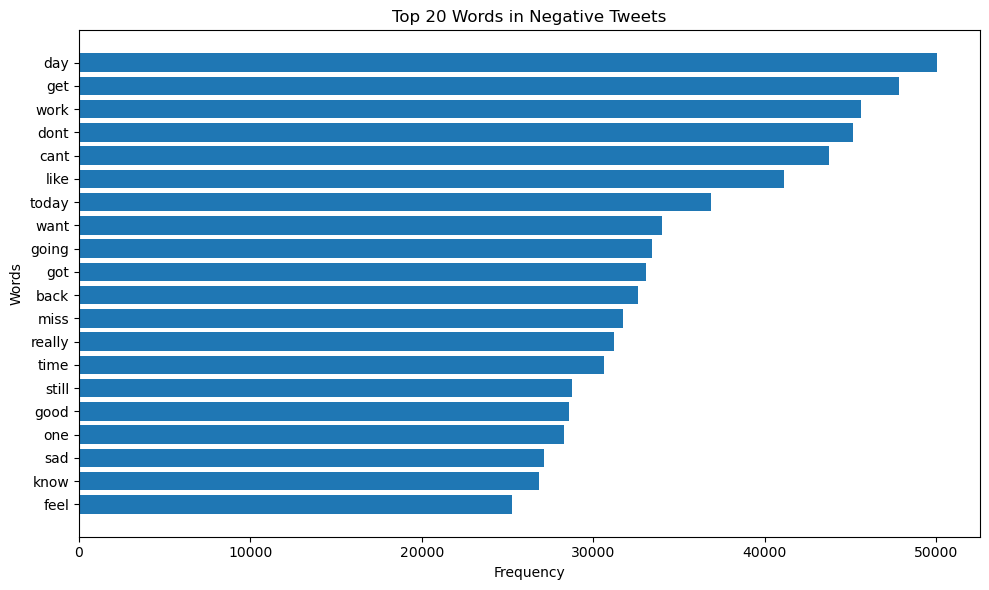

In [36]:
from collections import Counter
import re
import matplotlib.pyplot as plt

# Get negative tweets
negative_text = " ".join(
    df.loc[df["target"] == 0, "text"]
    .dropna()
    .astype(str)
)

# Extract words
negative_words = re.findall(
    r'\b[a-zA-Z]{3,}\b',
    negative_text.lower()
)

# Count words
negative_word_counts = Counter(negative_words)

# Top 20 words
top_negative = negative_word_counts.most_common(20)

print("Top 20 Negative Words:")
print(top_negative)

# Prepare chart
words = [x[0] for x in top_negative]
counts = [x[1] for x in top_negative]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(words[::-1], counts[::-1])

plt.title("Top 20 Words in Negative Tweets")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.tight_layout()
plt.show()

In [37]:
total_tweets = len(df)

negative_count = len(df[df["target"] == 0])
positive_count = len(df[df["target"] == 1])

negative_percentage = (negative_count / total_tweets) * 100
positive_percentage = (positive_count / total_tweets) * 100

print("========== SENTIMENT SUMMARY ==========")
print("Total Tweets:", total_tweets)
print("Negative Tweets:", negative_count)
print("Positive Tweets:", positive_count)
print("Negative Percentage:", round(negative_percentage, 2), "%")
print("Positive Percentage:", round(positive_percentage, 2), "%")

========== SENTIMENT SUMMARY ==========
Total Tweets: 1600000
Negative Tweets: 800000
Positive Tweets: 0
Negative Percentage: 50.0 %
Positive Percentage: 0.0 %


In [2]:
import os

print("Project files:")
print(os.listdir())

print("\nModel files:")
print(os.listdir("models"))

Project files:
['app.py', 'models', 'predictions.csv', 'READ.md', 'sent140_cleaned.csv', 'social media analysis.ipynb']

Model files:
['sentiment_model.pkl', 'vectorizer.pkl']


In [3]:
import joblib

model_test = joblib.load("models/sentiment_model.pkl")
vectorizer_test = joblib.load("models/vectorizer.pkl")

test_text = ["I love this amazing project!"]

test_vector = vectorizer_test.transform(test_text)

result = model_test.predict(test_vector)[0]

print("Prediction:", "Positive 😊" if result == 1 else "Negative 😞")

Prediction: Negative 😞
